# Trading Strategy Analysis
**Date:** [Insert Today's Date]  
**Author:** [Your Name]  
**Description:** This notebook analyzes price inefficiencies in the market using a quantitative trading strategy. The goal is to develop models for trading and manage risk effectively.


In [3]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import yfinance as yf;

Matplotlib is building the font cache; this may take a moment.


In [9]:
# Step 1: Fetch the Data
# Fetch historical data for a stock
tickers = ['AAPL', 'GOOGL', 'AMZN', 'TSLA']
data = yf.download(tickers, start='2020-01-01', end='2023-01-01')
data.head() # Display the first few rows of the dataset

[*********************100%***********************]  4 of 4 completed


Price                      Adj Close                                   \
Ticker                          AAPL       AMZN      GOOGL       TSLA   
Date                                                                    
2020-01-02 00:00:00+00:00  72.876122  94.900497  68.264961  28.684000   
2020-01-03 00:00:00+00:00  72.167603  93.748497  67.907845  29.534000   
2020-01-06 00:00:00+00:00  72.742661  95.143997  69.717865  30.102667   
2020-01-07 00:00:00+00:00  72.400551  95.343002  69.583206  31.270666   
2020-01-08 00:00:00+00:00  73.565201  94.598503  70.078476  32.809334   

Price                          Close                                   \
Ticker                          AAPL       AMZN      GOOGL       TSLA   
Date                                                                    
2020-01-02 00:00:00+00:00  75.087502  94.900497  68.433998  28.684000   
2020-01-03 00:00:00+00:00  74.357498  93.748497  68.075996  29.534000   
2020-01-06 00:00:00+00:00  74.949997  95.143997  69.890503  30.102667   
2020-01-07 00:00:00+00:00  74.597504  95.343002  69.755501  31.270666   
2020-01-08 00:00:00+00:00  75.797501  94.598503  70.251999  32.809334   

Price                           High             ...        Low             \
Ticker                          AAPL       AMZN  ...      GOOGL       TSLA   
Date                                             ...                         
2020-01-02 00:00:00+00:00  75.150002  94.900497  ...  67.324501  28.114000   
2020-01-03 00:00:00+00:00  75.144997  94.309998  ...  67.365997  29.128000   
2020-01-06 00:00:00+00:00  74.989998  95.184502  ...  67.550003  29.333332   
2020-01-07 00:00:00+00:00  75.224998  95.694504  ...  69.578003  30.224001   
2020-01-08 00:00:00+00:00  76.110001  95.550003  ...  69.631500  31.215334   

Price                           Open                                   \
Ticker                          AAPL       AMZN      GOOGL       TSLA   
Date                                                                    
2020-01-02 00:00:00+00:00  74.059998  93.750000  67.420502  28.299999   
2020-01-03 00:00:00+00:00  74.287498  93.224998  67.400002  29.366667   
2020-01-06 00:00:00+00:00  73.447502  93.000000  67.581497  29.364668   
2020-01-07 00:00:00+00:00  74.959999  95.224998  70.023003  30.760000   
2020-01-08 00:00:00+00:00  74.290001  94.902000  69.740997  31.580000   

Price                         Volume                                 
Ticker                          AAPL      AMZN     GOOGL       TSLA  
Date                                                                 
2020-01-02 00:00:00+00:00  135480400  80580000  27278000  142981500  
2020-01-03 00:00:00+00:00  146322800  75288000  23408000  266677500  
2020-01-06 00:00:00+00:00  118387200  81236000  46768000  151995000  
2020-01-07 00:00:00+00:00  108872000  80898000  34330000  268231500  
2020-01-08 00:00:00+00:00  132079200  70160000  35314000  467164500  

[5 rows x 24 columns]

In [15]:
# Step 2: Analyze the Data

# Calculate daily returns for each ticker
returns = data['Adj Close'].pct_change()

# Calculate moving averages (20-day and 50-day) for each ticker
moving_averages_20 = data['Adj Close'].rolling(window=20).mean()
moving_averages_50 = data['Adj Close'].rolling(window=50).mean()

# Combine the returns and moving averages into a single DataFrame
analysis = pd.concat([returns, moving_averages_20, moving_averages_50], axis=1)

# Flatten the multi-index columns
analysis.columns = ['_'.join(col).strip() for col in analysis.columns.values]

# Rename columns for clarity
analysis.rename(columns={
    'Adj Close_AAPL': 'Adj Close AAPL',
    'Adj Close_GOOGL': 'Adj Close GOOGL',
    'Adj Close_AMZN': 'Adj Close AMZN',
    'Adj Close_TSLA': 'Adj Close TSLA',
    'Returns_AAPL': 'Returns AAPL',
    'Returns_GOOGL': 'Returns GOOGL',
    'Returns_AMZN': 'Returns AMZN',
    'Returns_TSLA': 'Returns TSLA',
    'MA20_AAPL': 'MA20 AAPL',
    'MA20_GOOGL': 'MA20 GOOGL',
    'MA20_AMZN': 'MA20 AMZN',
    'MA20_TSLA': 'MA20 TSLA',
    'MA50_AAPL': 'MA50 AAPL',
    'MA50_GOOGL': 'MA50 GOOGL',
    'MA50_AMZN': 'MA50 AMZN',
    'MA50_TSLA': 'MA50 TSLA'
}, inplace=True)

# Drop NaN values from the analysis DataFrame
analysis.dropna(inplace=True)

# Display the first few rows of the analysis DataFrame
print(analysis.head())


                            A_A_P_L   A_M_Z_N  G_O_O_G_L   T_S_L_A    A_A_P_L  \
Date                                                                            
2020-03-13 00:00:00+00:00  0.119808  0.064648   0.092412 -0.024851  71.172313   
2020-03-16 00:00:00+00:00 -0.128647 -0.053698  -0.116342 -0.185778  70.166139   
2020-03-17 00:00:00+00:00  0.043970  0.070266   0.041994 -0.033410  69.361833   
2020-03-18 00:00:00+00:00 -0.024480  0.012258  -0.024033 -0.160344  68.426070   
2020-03-19 00:00:00+00:00 -0.007662  0.027831   0.018768  0.183877  67.507697   

                             A_M_Z_N  G_O_O_G_L    T_S_L_A    A_A_P_L  \
Date                                                                    
2020-03-13 00:00:00+00:00  97.695725  67.727696  49.323766  74.286117   
2020-03-16 00:00:00+00:00  96.581425  66.616123  48.140566  74.006767   
2020-03-17 00:00:00+00:00  95.711850  65.615152  46.713233  73.793393   
2020-03-18 00:00:00+00:00  94.861300  64.533630  44.859233  73.5384

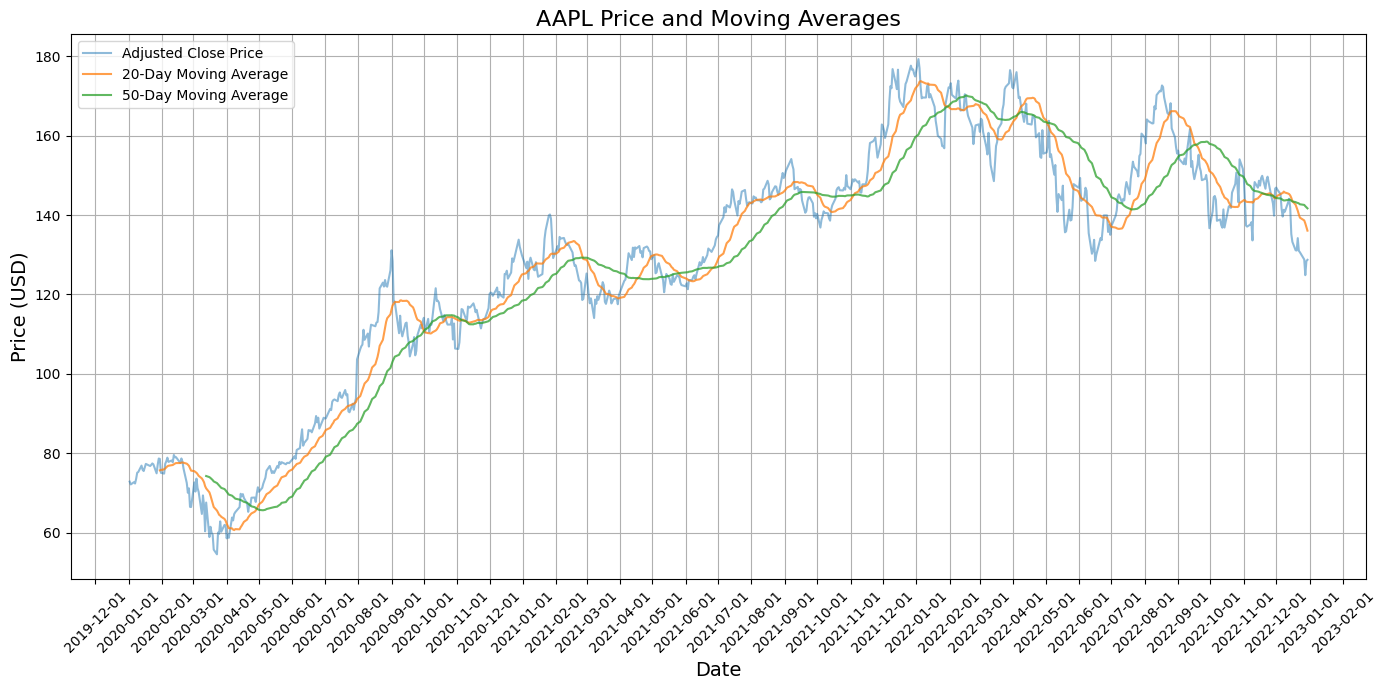

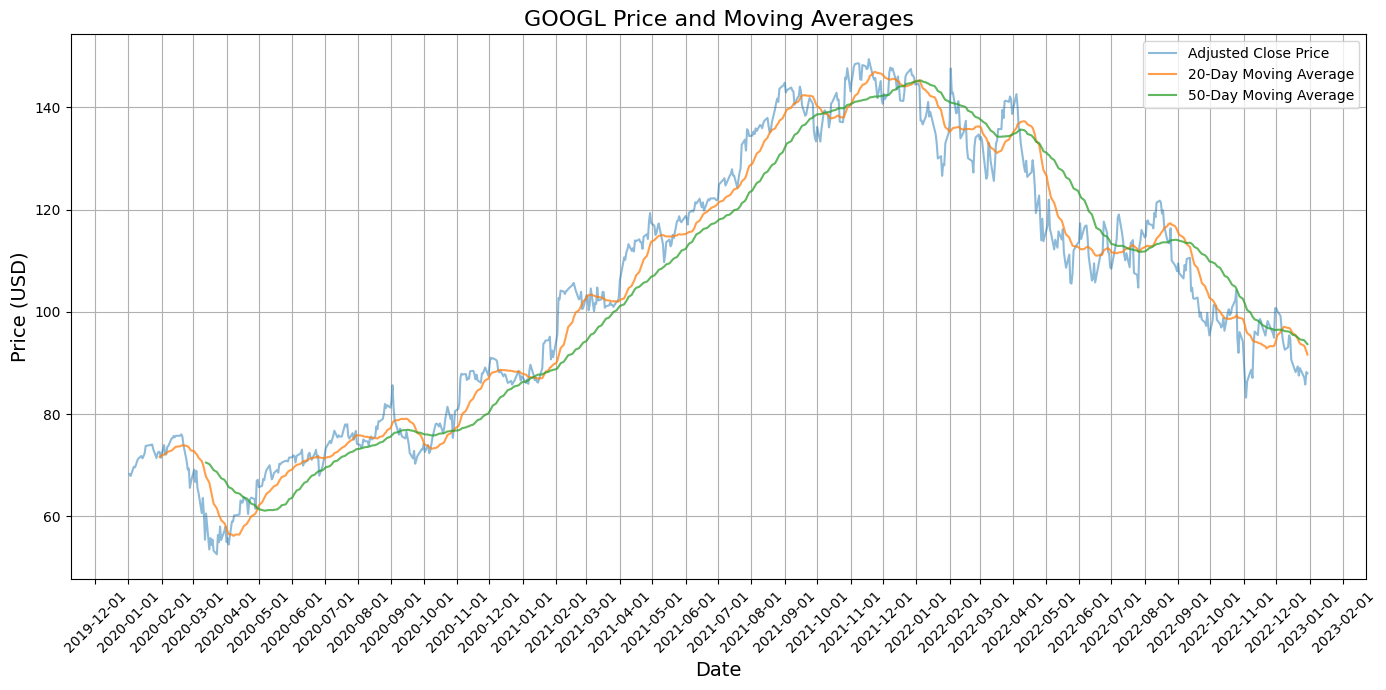

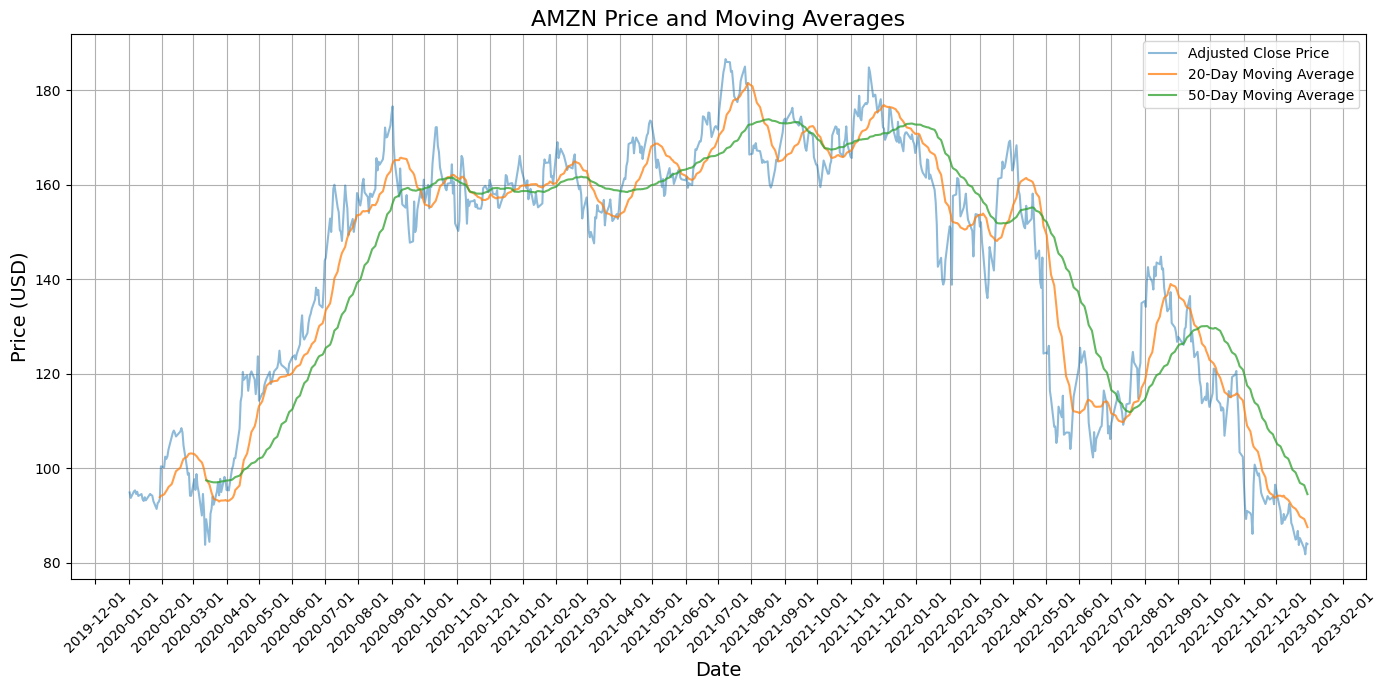

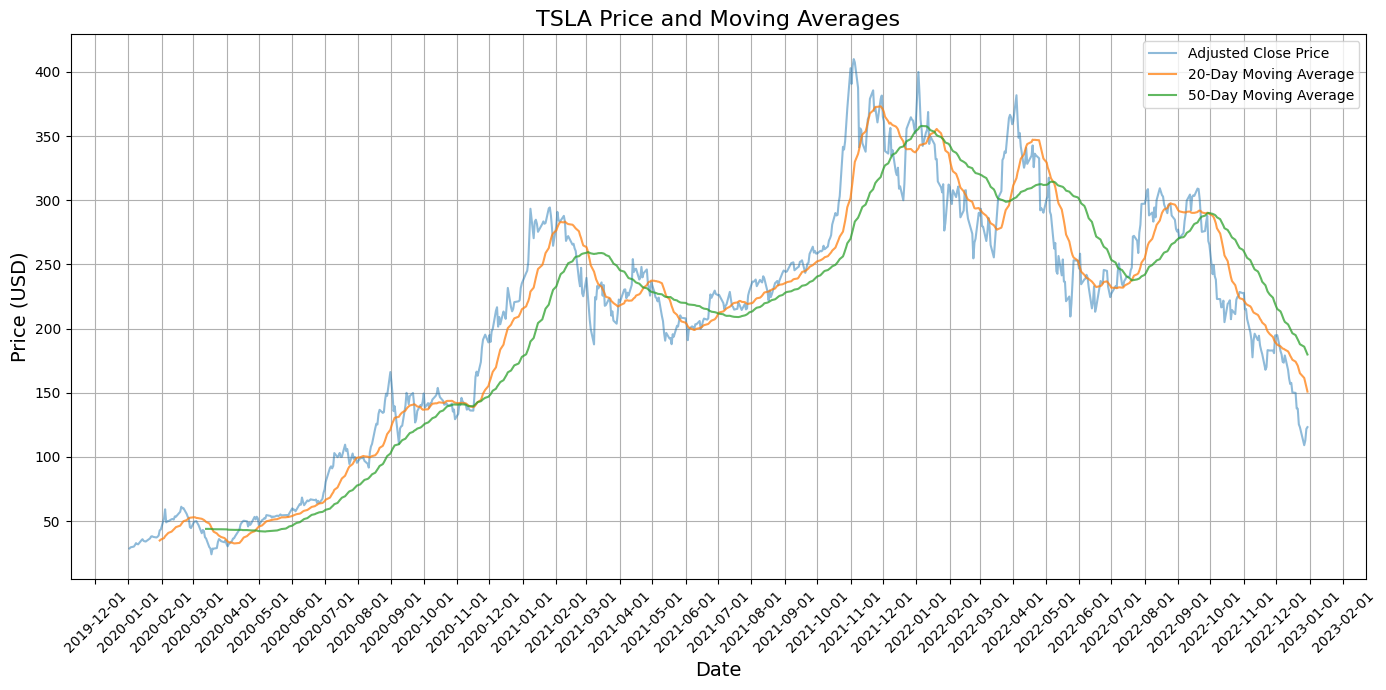

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Step 4: Visualize the data for each ticker
for ticker in tickers:
    plt.figure(figsize=(14, 7))
    plt.plot(data['Adj Close'][ticker], label='Adjusted Close Price', alpha=0.5)
    plt.plot(moving_averages_20[ticker], label='20-Day Moving Average', alpha=0.75)
    plt.plot(moving_averages_50[ticker], label='50-Day Moving Average', alpha=0.75)
    
    plt.title(f'{ticker} Price and Moving Averages', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Price (USD)', fontsize=14)
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()


C:\Users\bobby\AppData\Local\Temp\ipykernel_23924\1695796451.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Signal'][20:] = np.where(data['MA20'][20:]>data['MA50'][20:], 1, 0)
C:\Users\bobby\AppData\Local\Temp\ipykernel_23924\1695

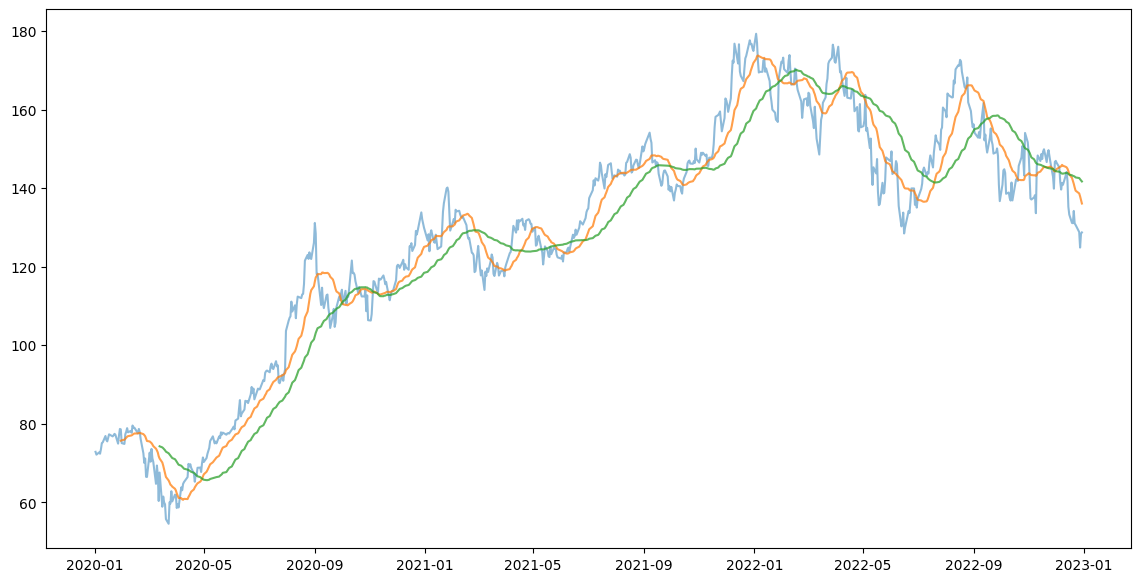

In [7]:
# Step 5: Develop a Trading Strategy
# Generate signals
data['Signal'] = 0
data['Signal'][20:] = np.where(data['MA20'][20:] > data['MA50'][20:], 1, 0)
data['Position'] = data['Signal'].diff()

# Ensure the 'Position' column exists before evaluation
if 'Position' in data.columns:
    # Step 6: Evaluate the Strategy
    # Calculate total returns
    total_return = (data['Adj Close'].iloc[-1] - data['Adj Close'].iloc[0]) / data['Adj Close'].iloc[0]

    # Calculate number of trades
    num_trades = data['Position'].dropna().count()

    # Calculate returns for each trade
    data['Trade Return'] = data['Adj Close'].pct_change().shift(-1) * data['Signal'].shift(1)

    # Calculate average return per trade
    avg_return_per_trade = data['Trade Return'].mean()

    # Print evaluation results
    print(f'Total Return: {total_return:.2%}')
    print(f'Number of Trades: {num_trades}')
    print(f'Average Return per Trade: {avg_return_per_trade:.2%}')
else:
    print("The 'Position' column does not exist in the DataFrame.")


In [19]:
# Step 6: Evaluate the Strategy
# Calculate total returns
total_return = (data['Adj Close'].iloc[-1] - data['Adj Close'].iloc[0]) / data['Adj Close'].iloc[0]

# Calculate number of trades
num_trades = data['Position'].dropna().count()

# Calculate returns for each trade
data['Trade Return'] = data['Adj Close'].pct_change().shift(-1) * data['Signal'].shift(1)

# Calculate average return per trade
avg_return_per_trade = data['Trade Return'].mean()

# Print evaluation results
print(f'Total Return: {total_return:.2%}')
print(f'Number of Trades: {num_trades}')
print(f'Average Return per Trade: {avg_return_per_trade:.2%}')


KeyError: 'Position'

## Conclusion
This notebook demonstrates a simple quantitative trading strategy based on moving averages. Future work could involve optimizing the parameters or incorporating additional data sources for improved predictions.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Step 1: Fetch the Data
tickers = ['AAPL', 'GOOGL', 'AMZN', 'TSLA']
data = yf.download(tickers, start='2020-01-01', end='2023-01-01')

# Step 2: Calculate Adjusted Close Returns
returns = data['Adj Close'].pct_change()

# Step 3: Calculate Moving Averages
moving_averages_20 = data['Adj Close'].rolling(window=20).mean()
moving_averages_50 = data['Adj Close'].rolling(window=50).mean()

# Develop a Trading Strategy
# Generate signals
data['Signal'] = 0

# Ensure we compare the moving averages correctly
data['Signal'][20:] = (moving_averages_20[20:] > moving_averages_50[20:]).astype(int)

# Create the Position column
data['Position'] = data['Signal'].diff()

# Check if 'Position' column was created
print("DataFrame columns:", data.columns)

# Evaluate the Strategy
if 'Position' in data.columns:
    # Calculate total returns
    total_return = (data['Adj Close'].iloc[-1] - data['Adj Close'].iloc[0]) / data['Adj Close'].iloc[0]

    # Calculate number of trades
    num_trades = data['Position'].dropna().count()

    # Calculate returns for each trade
    data['Trade Return'] = data['Adj Close'].pct_change().shift(-1) * data['Signal'].shift(1)

    # Calculate average return per trade
    avg_return_per_trade = data['Trade Return'].mean()

    # Print evaluation results
    print(f'Total Return: {total_return:.2%}')
    print(f'Number of Trades: {num_trades}')
    print(f'Average Return per Trade: {avg_return_per_trade:.2%}')
else:
    print("The 'Position' column does not exist in the DataFrame.")


[*********************100%***********************]  4 of 4 completed
C:\Users\bobby\AppData\Local\Temp\ipykernel_2532\3921255009.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'][20:] = (moving_averages_20[20:] > moving_averages_50[20:]).astype(int)


ValueError: setting an array element with a sequence.